## Importando librerías

In [2]:
from keras.datasets import mnist
from keras import layers, models
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

2026-04-21 16:14:39.437413: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776788079.670001      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776788079.743863      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776788080.294767      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776788080.294813      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776788080.294816      55 computation_placer.cc:177] computation placer alr

## Nuestro set de datos

In [3]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
train_data.shape

(60000, 28, 28)

In [5]:
test_data.shape

(10000, 28, 28)

In [6]:
train_data[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

<function matplotlib.pyplot.show(close=None, block=None)>

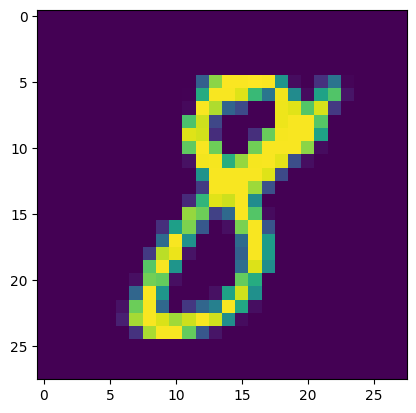

In [7]:
plt.imshow(train_data[85])
plt.show

In [8]:
train_labels[85]

np.uint8(8)

## Creando un modelo de datos

In [9]:
model = models.Sequential()
model.add(layers.Dense(512,activation='relu', input_shape=(28*28,)))
model.add(layers.Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776788104.539398      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776788104.545611      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## Limpieza de datos

In [12]:
x_train = train_data.reshape((60000,28*28))
x_train = x_train.astype('float32')/255

x_test = test_data.reshape((10000,28*28))
x_test = x_test.astype('float32')/255

In [13]:
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [14]:
train_labels[85]

np.uint8(8)

In [15]:
y_train[85]

array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])

## Entrenando el modelo

In [16]:
model.fit(x_train, y_train, epochs=5, batch_size=128)

Epoch 1/5


I0000 00:00:1776788107.425797     130 service.cc:152] XLA service 0x7885bc003b30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776788107.425841     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776788107.425845     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776788107.636090     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


 63/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7262 - loss: 0.9306

I0000 00:00:1776788108.554917     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8731 - loss: 0.4405
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9655 - loss: 0.1184
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9793 - loss: 0.0721
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9845 - loss: 0.0521
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9890 - loss: 0.0369


## Evaluando sobre data de test

In [17]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9742 - loss: 0.0797


[0.06677329540252686, 0.9782999753952026]

✅ Imagen encontrada: /kaggle/input/datasets/brigitteadhar49/numeros/Captura de pantalla 2026-04-21 110707.png


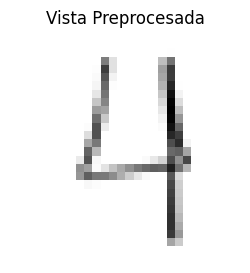

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
🔮 El modelo dice que es el número: 3
💪 Confianza: 99.49%

📊 Probabilidades detectadas:
Dígito 3: 99.49%


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import os

# 1. Configuración de rutas
input_dir = '/kaggle/input/datasets/brigitteadhar49/numeros' 
# Nombre del archivo específico
archivo_nombre = '/kaggle/input/datasets/brigitteadhar49/numeros/Captura de pantalla 2026-04-21 110707.png'
ruta_completa = os.path.join(input_dir, archivo_nombre)

# 2. Definición de la función de procesamiento
def preparar_imagen_kaggle(ruta):
    # Convertir a escala de grises
    img = Image.open(ruta).convert('L') 
    
    # IMPORTANTE: Invertir colores si es papel blanco y tinta negra
    # MNIST necesita fondo negro y letra blanca
    img = ImageOps.invert(img) 
    
    # Redimensionar a 28x28 píxeles
    img = img.resize((28, 28)) 
    
    # Convertir a array numérico
    img_array = np.array(img)
    
    # Normalizar valores (0-1)
    img_array = img_array.astype('float32') / 255.0 
    
    # Aplanar para la entrada del modelo (1, 784)
    img_array = img_array.reshape(1, 28 * 28) 
    
    return img_array, img

# 3. Verificación y ejecución
if not os.path.exists(ruta_completa):
    print(f"❌ Error: No encuentro el archivo en {ruta_completa}")
    print("Revisando archivos disponibles...")
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            print(os.path.join(dirname, filename))
else:
    print(f"✅ Imagen encontrada: {ruta_completa}")

    # Procesar la imagen
    imagen_procesada, imagen_original = preparar_imagen_kaggle(ruta_completa)

    # Mostrar la imagen que verá el modelo
    plt.figure(figsize=(3,3))
    plt.imshow(imagen_original, cmap='gray')
    plt.title("Vista Preprocesada")
    plt.axis('off')
    plt.show()

    # 4. Predicción
    prediccion = model.predict(imagen_procesada)
    numero_predicho = np.argmax(prediccion)
    confianza = np.max(prediccion) * 100

    print(f"🔮 El modelo dice que es el número: {numero_predicho}")
    print(f"💪 Confianza: {confianza:.2f}%")
    
    # Mostrar desglose de probabilidades
    print("\n📊 Probabilidades detectadas:")
    for i, prob in enumerate(prediccion[0]):
        if prob > 0.01: # Solo mostrar si tiene más del 1%
            print(f"Dígito {i}: {prob*100:.2f}%")

🔎 Iniciando predicción individual para 9 archivos...

--------------------------------------------------
ARCHIVO: Captura de pantalla 2026-04-21 110648.png
PREDICCIÓN: 3 (Confianza: 90.81%)


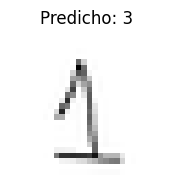

--------------------------------------------------
ARCHIVO: Captura de pantalla 2026-04-21 110743.png
PREDICCIÓN: 3 (Confianza: 83.52%)


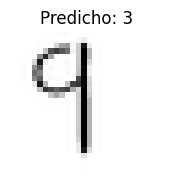

--------------------------------------------------
ARCHIVO: Captura de pantalla 2026-04-21 110732.png
PREDICCIÓN: 3 (Confianza: 99.98%)


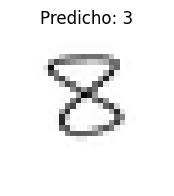

--------------------------------------------------
ARCHIVO: Captura de pantalla 2026-04-21 110729.png
PREDICCIÓN: 3 (Confianza: 79.64%)


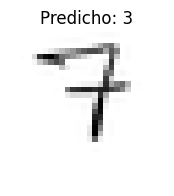

--------------------------------------------------
ARCHIVO: Captura de pantalla 2026-04-21 110720.png
PREDICCIÓN: 3 (Confianza: 99.11%)


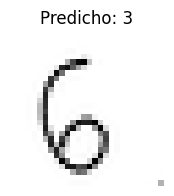

--------------------------------------------------
ARCHIVO: Captura de pantalla 2026-04-21 110654.png
PREDICCIÓN: 3 (Confianza: 98.38%)


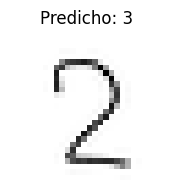

--------------------------------------------------
ARCHIVO: Captura de pantalla 2026-04-21 110702.png
PREDICCIÓN: 3 (Confianza: 94.82%)


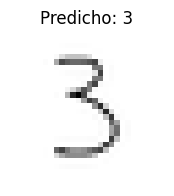

--------------------------------------------------
ARCHIVO: Captura de pantalla 2026-04-21 110711.png
PREDICCIÓN: 3 (Confianza: 99.46%)


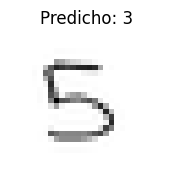

--------------------------------------------------
ARCHIVO: Captura de pantalla 2026-04-21 110707.png
PREDICCIÓN: 3 (Confianza: 99.60%)


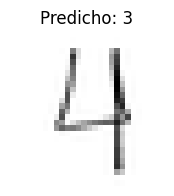

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import os

# 1. Carpeta de tus números
input_dir = '/kaggle/input/datasets/brigitteadhar49/numeros'

# 2. Función de limpieza extrema (para que no te salgan todos 3)
def procesar_individual(ruta):
    # Abrir y convertir a escala de grises
    img = Image.open(ruta).convert('L')
    
    # Invertir: Papel blanco -> Fondo negro
    img = ImageOps.invert(img)
    
    # Thresholding: Borrar sombras. Todo lo que no sea blanco brillante se va a negro.
    # Si el número desaparece, baja el 150 a 100.
    img_np = np.array(img)
    img_np = (img_np > 150) * 255 
    
    # Convertir de nuevo a imagen y redimensionar
    img_limpia = Image.fromarray(img_np.astype('uint8'))
    img_28x28 = img_limpia.resize((28, 28), Image.Resampling.LANCZOS)
    
    # Preparar vector para el modelo Dense
    img_final = np.array(img_28x28).astype('float32') / 255.0
    img_vector = img_final.reshape(1, 784)
    
    return img_vector, img_28x28

# 3. Obtener lista de archivos
archivos = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# 4. Predicción individual por cada archivo
print(f"🔎 Iniciando predicción individual para {len(archivos)} archivos...\n")

for nombre in archivos:
    ruta_archivo = os.path.join(input_dir, nombre)
    
    # Procesar
    datos, img_vista = procesar_individual(ruta_archivo)
    
    # Predecir
    prediccion = model.predict(datos, verbose=0)
    resultado = np.argmax(prediccion)
    confianza = np.max(prediccion) * 100
    
    # Mostrar resultados de este número específico
    print("-" * 50)
    print(f"ARCHIVO: {nombre}")
    print(f"PREDICCIÓN: {resultado} (Confianza: {confianza:.2f}%)")
    
    plt.figure(figsize=(2, 2))
    plt.imshow(img_vista, cmap='gray')
    plt.title(f"Predicho: {resultado}")
    plt.axis('off')
    plt.show()

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8697 - loss: 0.4421
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9664 - loss: 0.1157
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9788 - loss: 0.0716
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9855 - loss: 0.0507
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9883 - loss: 0.0390
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9768 - loss: 0.0783

Accuracy en test: 0.9802


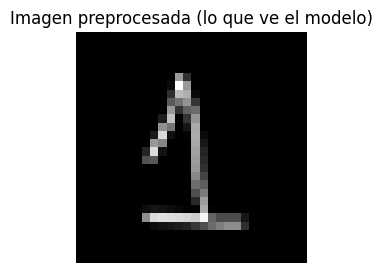

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


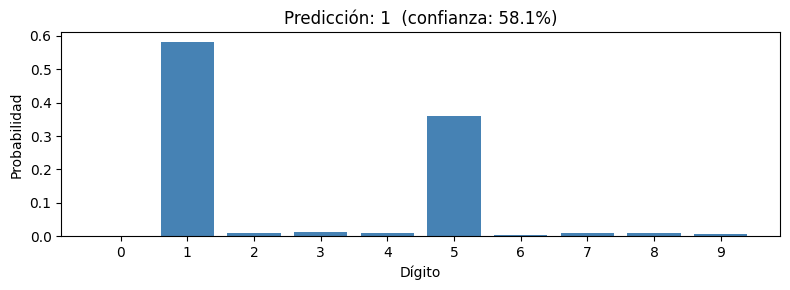


>>> El modelo predice que el número es: 1
>>> Confianza: 58.1%


KeyboardInterrupt: 

In [43]:
# %% [markdown]
# ## Predicción con imagen externa (foto o archivo)

# %% [code]
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from keras.datasets import mnist
from keras import layers, models
from keras.utils import to_categorical

# ── 1. Cargar y preparar datos ──────────────────────────────────────────────
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

x_train = train_data.reshape((60000, 28*28)).astype('float32') / 255
x_test  = test_data.reshape((10000, 28*28)).astype('float32') / 255
y_train = to_categorical(train_labels)
y_test  = to_categorical(test_labels)

# ── 2. Crear y entrenar el modelo ────────────────────────────────────────────
model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(28*28,)),
    layers.Dense(10,  activation='softmax')
])

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, batch_size=128)

# ── 3. Evaluar en test ───────────────────────────────────────────────────────
loss, acc = model.evaluate(x_test, y_test)
print(f"\nAccuracy en test: {acc:.4f}")

# %% [markdown]
# ## Función para predecir desde una imagen externa

# %% [code]
def predecir_imagen(ruta_imagen):
    """
    Recibe la ruta de una imagen (foto de un número escrito a mano),
    la preprocesa al formato MNIST (28x28, escala de grises, fondo negro)
    y devuelve la predicción del modelo.
    """
    # Abrir y convertir a escala de grises
    img = Image.open(ruta_imagen).convert('L')

    # Redimensionar a 28x28
    img = img.resize((28, 28))

    # Convertir a array numpy
    img_array = np.array(img).astype('float32')

    # MNIST tiene fondo negro y dígito blanco.
    # Si tu foto tiene fondo blanco (papel), invertimos los colores.
    if img_array.mean() > 127:
        img_array = 255 - img_array

    # Normalizar entre 0 y 1
    img_array = img_array / 255.0

    # Mostrar cómo la ve el modelo
    plt.figure(figsize=(3, 3))
    plt.imshow(img_array, cmap='gray')
    plt.title("Imagen preprocesada (lo que ve el modelo)")
    plt.axis('off')
    plt.show()

    # Aplanar y predecir
    img_flat = img_array.reshape(1, 28*28)
    predicciones = model.predict(img_flat)

    digit_predicho   = np.argmax(predicciones)
    confianza        = predicciones[0][digit_predicho] * 100

    # Mostrar probabilidades de cada clase
    plt.figure(figsize=(8, 3))
    plt.bar(range(10), predicciones[0], color='steelblue')
    plt.xticks(range(10))
    plt.xlabel("Dígito")
    plt.ylabel("Probabilidad")
    plt.title(f"Predicción: {digit_predicho}  (confianza: {confianza:.1f}%)")
    plt.tight_layout()
    plt.show()

    print(f"\n>>> El modelo predice que el número es: {digit_predicho}")
    print(f">>> Confianza: {confianza:.1f}%")

    return digit_predicho

# %% [markdown]
# ## Usar la función — pon la ruta de tu imagen aquí

# %% [code]
# ── Opción A: ruta a un archivo local ───────────────────────────────────────
predecir_imagen("/kaggle/input/datasets/brigitteadhar49/numeros/Captura de pantalla 2026-04-21 110648.png")   # <-- cambia por tu ruta

# %% [code]
# ── Opción B: si estás en Google Colab, sube el archivo primero ─────────────
from google.colab import files
uploaded = files.upload()                        # abre el selector de archivos
nombre   = list(uploaded.keys())[0]             # toma el primer archivo subido
predecir_imagen(nombre)

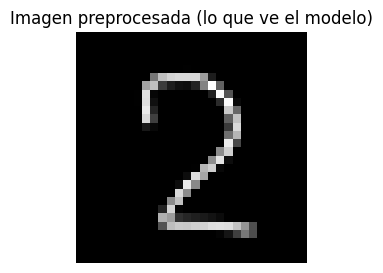

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


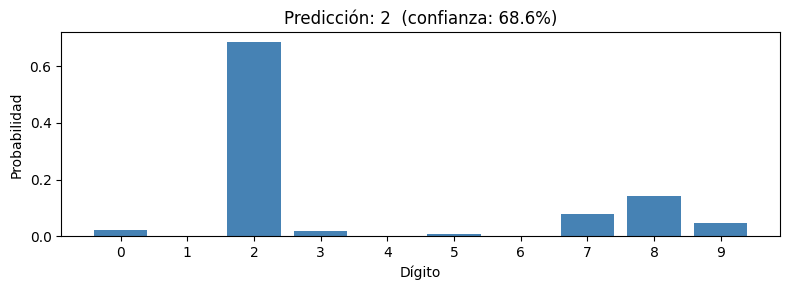


>>> El modelo predice que el número es: 2
>>> Confianza: 68.6%


np.int64(2)

In [44]:
predecir_imagen("/kaggle/input/datasets/brigitteadhar49/numeros/Captura de pantalla 2026-04-21 110654.png")   # <-- cambia por tu ruta



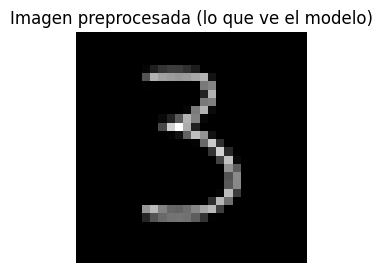

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


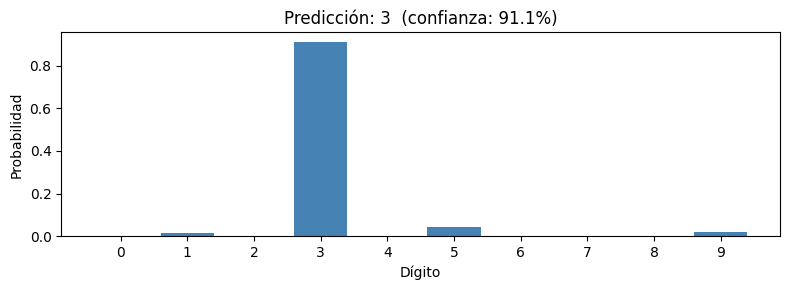


>>> El modelo predice que el número es: 3
>>> Confianza: 91.1%


np.int64(3)

In [45]:
predecir_imagen("/kaggle/input/datasets/brigitteadhar49/numeros/Captura de pantalla 2026-04-21 110702.png")   # <-- cambia por tu ruta



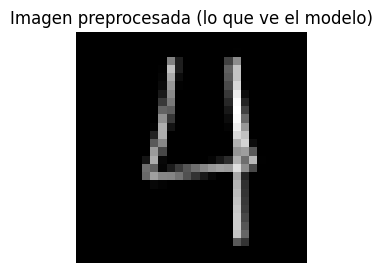

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


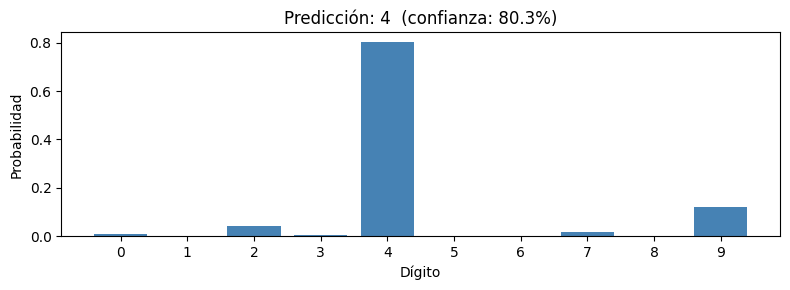


>>> El modelo predice que el número es: 4
>>> Confianza: 80.3%


np.int64(4)

In [46]:
predecir_imagen("/kaggle/input/datasets/brigitteadhar49/numeros/Captura de pantalla 2026-04-21 110707.png")   # <-- cambia por tu ruta



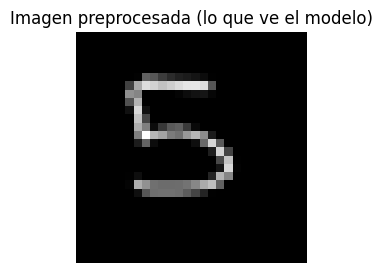

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


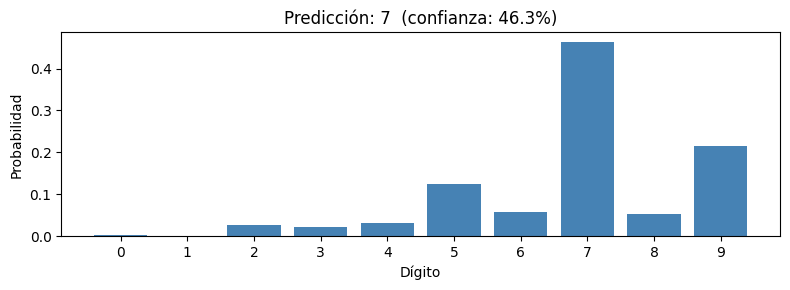


>>> El modelo predice que el número es: 7
>>> Confianza: 46.3%


np.int64(7)

In [48]:
predecir_imagen("/kaggle/input/datasets/brigitteadhar49/numeros/Captura de pantalla 2026-04-21 110711.png")   # <-- cambia por tu ruta


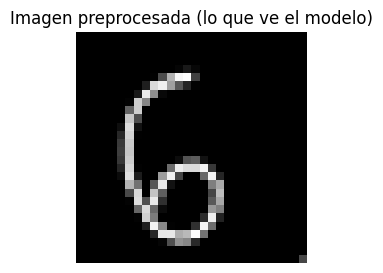

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


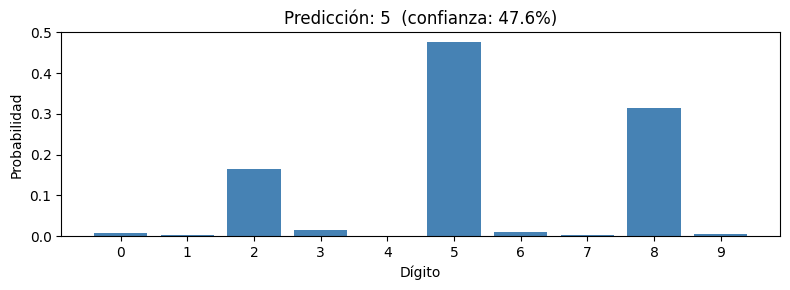


>>> El modelo predice que el número es: 5
>>> Confianza: 47.6%


np.int64(5)

In [54]:
predecir_imagen("/kaggle/input/datasets/brigitteadhar49/numeros/Captura de pantalla 2026-04-21 110720.png")   # <-- cambia por tu ruta


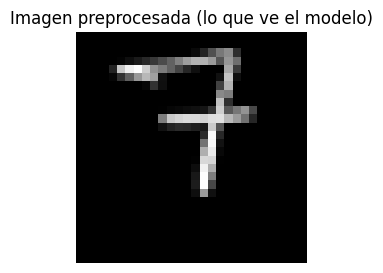

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


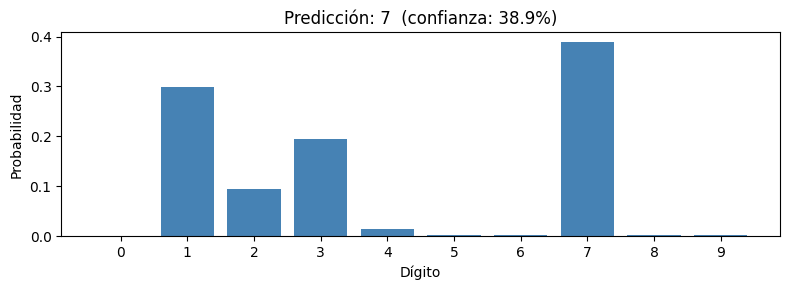


>>> El modelo predice que el número es: 7
>>> Confianza: 38.9%


np.int64(7)

In [50]:
predecir_imagen("/kaggle/input/datasets/brigitteadhar49/numeros/Captura de pantalla 2026-04-21 110729.png")   # <-- cambia por tu ruta



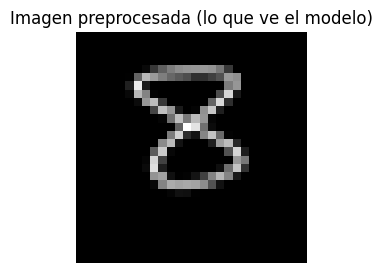

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


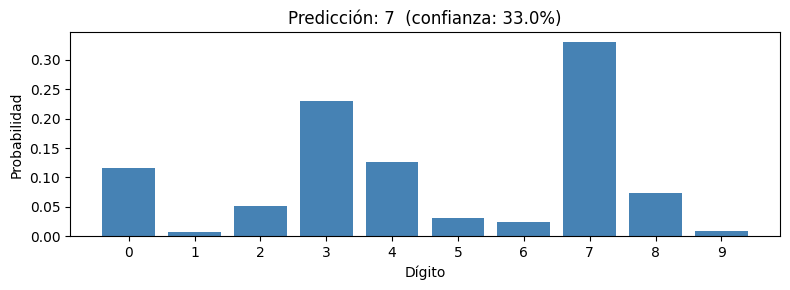


>>> El modelo predice que el número es: 7
>>> Confianza: 33.0%


np.int64(7)

In [53]:
predecir_imagen("/kaggle/input/datasets/brigitteadhar49/numeros/Captura de pantalla 2026-04-21 110732.png")   # <-- cambia por tu ruta



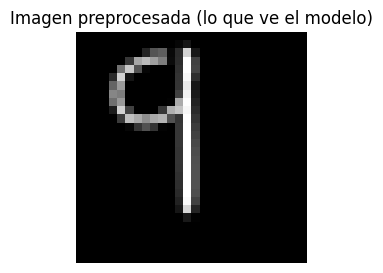

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


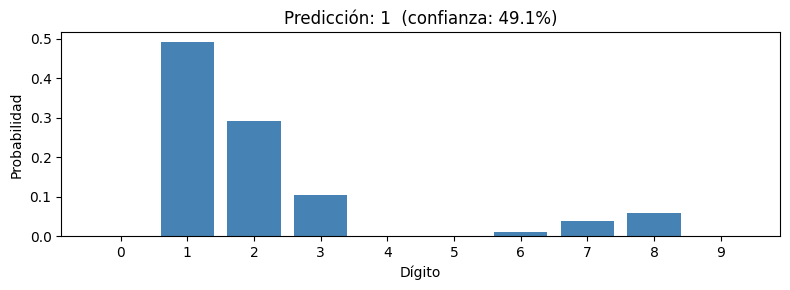


>>> El modelo predice que el número es: 1
>>> Confianza: 49.1%


np.int64(1)

In [52]:
predecir_imagen("/kaggle/input/datasets/brigitteadhar49/numeros/Captura de pantalla 2026-04-21 110743.png")   # <-- cambia por tu ruta

